## Install Required Packages

Uncomment and run if packages are not installed.

In [1]:
# !pip install transformers datasets evaluate sacrebleu torch sentencepiece accelerate peft pandas matplotlib seaborn

## Imports

In [2]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline
from peft import PeftModel
import evaluate
import torch
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050
BF16 supported: True


## Configuration

Set up paths and model configurations for validation.

In [3]:
# Directories
DATA_DIR = Path("../data/splits")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Model configurations
MBART_MODEL = "facebook/mbart-large-50"
NLLB_MODEL = "facebook/nllb-200-distilled-600M"

# Validation parameters
MAX_LENGTH = 128
BATCH_SIZE = 32  # ⚡ Increased from 16 for 2x faster validation
NUM_BEAMS = 5  # For beam search during generation
USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

# Language pair configurations
LANGUAGE_PAIRS = {
    "en-tl": {
        "src_lang": "en",
        "tgt_lang": "tl",
        "name": "English-Tagalog",
        "mbart_src": "en_XX",
        "mbart_tgt": "tl_XX",
        "nllb_src": "eng_Latn",
        "nllb_tgt": "tgl_Latn"
    },
}

print("Validation Configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Num beams: {NUM_BEAMS}")
print(f"  BF16 enabled: {USE_BF16}")
print(f"\nLanguage pairs: {len(LANGUAGE_PAIRS)}")
for pair_name, config in LANGUAGE_PAIRS.items():
    print(f"  - {pair_name}: {config['name']}")

Validation Configuration:
  Batch size: 32
  Num beams: 5
  BF16 enabled: True

Language pairs: 1
  - en-tl: English-Tagalog


## Helper Functions

Functions to load test data, models, and calculate metrics.

In [4]:
def load_test_data(pair_name):
    """Load test split for a language pair."""
    src_code, tgt_code = pair_name.split("-")
    pair_dir = DATA_DIR / pair_name
    
    with open(pair_dir / f"test.{src_code}", "r", encoding="utf-8") as f:
        src_sentences = [line.strip() for line in f.readlines()]
    
    with open(pair_dir / f"test.{tgt_code}", "r", encoding="utf-8") as f:
        tgt_sentences = [line.strip() for line in f.readlines()]
    
    print(f"Loaded {pair_name} test set: {len(src_sentences)} sentence pairs")
    return src_sentences, tgt_sentences


def load_model_and_tokenizer(model_path, base_model_name, is_lora=False):
    """Load model and tokenizer from path with optimizations."""
    print(f"Loading model from: {model_path}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    # Determine dtype for faster inference
    dtype = torch.bfloat16 if USE_BF16 else torch.float32
    
    if is_lora:
        # Load base model then LoRA adapters with optimized dtype
        print(f"  Loading base model: {base_model_name}")
        base_model = AutoModelForSeq2SeqLM.from_pretrained(
            base_model_name,
            torch_dtype=dtype
        )
        print(f"  Loading LoRA adapters...")
        model = PeftModel.from_pretrained(base_model, model_path)
        model = model.merge_and_unload()  # Merge LoRA weights for faster inference
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_path,
            torch_dtype=dtype
        )
    
    # Move to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    
    # ⚡ Enable optimizations
    if device == "cuda":
        torch.backends.cudnn.benchmark = True
    
    print(f"  Model loaded on: {device} ({dtype})")
    return model, tokenizer, device


def translate_batch(model, tokenizer, source_texts, src_lang, tgt_lang, device, batch_size=16):
    """Translate a batch of sentences with optimizations."""
    translations = []
    
    # Set source language
    tokenizer.src_lang = src_lang
    
    # ⚡ Pre-compute forced_bos_token_id once (not in loop)
    if hasattr(tokenizer, 'lang_code_to_id'):
        # mBART tokenizer
        forced_bos_token_id = tokenizer.lang_code_to_id[tgt_lang]
    else:
        # NLLB tokenizer - convert language code to token ID
        forced_bos_token_id = tokenizer.convert_tokens_to_ids(tgt_lang)
    
    # ⚡ Use torch.inference_mode() for faster inference (vs no_grad)
    with torch.inference_mode():
        for i in tqdm(range(0, len(source_texts), batch_size), desc="Translating"):
            batch = source_texts[i:i+batch_size]
            
            # Tokenize
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH
            ).to(device)
            
            # Generate translations
            generated_tokens = model.generate(
                **inputs,
                forced_bos_token_id=forced_bos_token_id,
                num_beams=NUM_BEAMS,
                max_length=MAX_LENGTH,
                early_stopping=True,
                use_cache=True,  # ⚡ Enable KV cache for faster generation
                do_sample=False  # ⚡ Deterministic (required for reproducible scores)
            )
            
            # Decode
            batch_translations = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)
            translations.extend(batch_translations)
            
            # ⚡ Clear batch from GPU memory
            del inputs, generated_tokens
            if device == "cuda":
                torch.cuda.empty_cache()
    
    return translations


def calculate_metrics(predictions, references):
    """Calculate BLEU, chrF, and TER scores."""
    # Load metrics
    bleu = evaluate.load("sacrebleu")
    chrf = evaluate.load("chrf")
    ter = evaluate.load("ter")
    
    # Format references for sacrebleu (list of lists)
    references_formatted = [[ref] for ref in references]
    
    # Calculate scores
    bleu_score = bleu.compute(predictions=predictions, references=references_formatted)
    chrf_score = chrf.compute(predictions=predictions, references=references_formatted)
    ter_score = ter.compute(predictions=predictions, references=references)
    
    return {
        "bleu": bleu_score["score"],
        "chrf": chrf_score["score"],
        "ter": ter_score["score"]
    }


print("✓ Helper functions defined")

✓ Helper functions defined


## Validate Single Model

Test a single model on a language pair test set.

In [ ]:
def validate_model(model_path, pair_name, model_type, base_model_name, is_lora=False):
    """Validate a single model on test set."""
    print("\n" + "="*80)
    print(f"VALIDATING: {model_type} - {pair_name}")
    print("="*80)
    
    # Check if model exists
    if not Path(model_path).exists():
        print(f"❌ Model not found: {model_path}")
        return None
    
    # Load test data
    src_sentences, ref_sentences = load_test_data(pair_name)
    
    # Load model
    model, tokenizer, device = load_model_and_tokenizer(model_path, base_model_name, is_lora)
    
    # Get language codes
    pair_config = LANGUAGE_PAIRS[pair_name]
    if "nllb" in base_model_name.lower():
        src_lang = pair_config["nllb_src"]
        tgt_lang = pair_config["nllb_tgt"]
    else:
        src_lang = pair_config["mbart_src"]
        tgt_lang = pair_config["mbart_tgt"]
    
    print(f"\nTranslating {len(src_sentences)} sentences ({src_lang} → {tgt_lang})...")
    
    # Translate
    start_time = datetime.now()
    translations = translate_batch(model, tokenizer, src_sentences, src_lang, tgt_lang, device, BATCH_SIZE)
    end_time = datetime.now()
    translation_time = (end_time - start_time).total_seconds()
    
    # Calculate metrics
    print("\nCalculating metrics...")
    metrics = calculate_metrics(translations, ref_sentences)
    
    # Print results
    print("\n" + "-"*80)
    print("RESULTS:")
    print("-"*80)
    print(f"  BLEU Score:  {metrics['bleu']:.2f}")
    print(f"  chrF Score:  {metrics['chrf']:.2f}")
    print(f"  TER Score:   {metrics['ter']:.2f}")
    print(f"  Translation Time: {translation_time:.1f}s ({len(src_sentences)/translation_time:.1f} sent/s)")
    print("-"*80)
    
    # Show sample translations
    print("\nSample Translations:")
    for i in range(min(3, len(src_sentences))):
        print(f"\n[{i+1}]")
        print(f"  Source:      {src_sentences[i]}")
        print(f"  Reference:   {ref_sentences[i]}")
        print(f"  Translation: {translations[i]}")
    
    # Prepare result dictionary
    result = {
        "model_type": model_type,
        "model_path": str(model_path),
        "pair_name": pair_name,
        "base_model": base_model_name,
        "is_lora": is_lora,
        "test_size": len(src_sentences),
        "metrics": metrics,
        "translation_time": translation_time,
        "sentences_per_second": len(src_sentences) / translation_time,
        "timestamp": datetime.now().isoformat()
    }
    
    # Clean up
    del model
    torch.cuda.empty_cache()
    
    return result, translations, src_sentences, ref_sentences


print("✓ Validation function defined")

✓ Validation function defined


## Validate Specific Model

Example: Validate the Tagalog baseline NLLB model.

In [ ]:
# Example: Validate Tagalog baseline NLLB model
model_path = MODELS_DIR / "tagalog_baseline_nllb_lora_bf16" / "final_model"
pair_name = "en-tl"
model_type = "Tagalog Baseline (NLLB + LoRA + BF16)"

result, translations, src_sentences, ref_sentences = validate_model(
    model_path=model_path,
    pair_name=pair_name,
    model_type=model_type,
    base_model_name=NLLB_MODEL,
    is_lora=True
)

# Save results
if result:
    results_file = RESULTS_DIR / f"validation_{pair_name}_baseline.json"
    with open(results_file, "w") as f:
        json.dump(result, f, indent=2)
    print(f"\n✓ Results saved to: {results_file}")
    
    # Save translations as text file
    translations_file = RESULTS_DIR / f"translations_{pair_name}_baseline.txt"
    with open(translations_file, "w", encoding="utf-8") as f:
        f.write("\n".join(translations))
    print(f"✓ Translations saved to: {translations_file}")
    
    # Save translations as CSV with source and reference
    df_translations = pd.DataFrame({
        "source": src_sentences,
        "reference": ref_sentences,
        "translation": translations
    })
    translations_csv = RESULTS_DIR / f"translations_{pair_name}_baseline.csv"
    df_translations.to_csv(translations_csv, index=False, encoding="utf-8")
    print(f"✓ Translations CSV saved to: {translations_csv}")



VALIDATING: Tagalog Baseline (NLLB + LoRA + BF16) - en-tl
Loaded en-tl test set: 773 sentence pairs
Loading model from: ..\models\tagalog_baseline_nllb_lora_bf16\final_model
  Loading base model: facebook/nllb-200-distilled-600M
  Loading base model: facebook/nllb-200-distilled-600M


`torch_dtype` is deprecated! Use `dtype` instead!


  Loading LoRA adapters...
  Model loaded on: cuda (torch.bfloat16)

Translating 773 sentences (eng_Latn → tgl_Latn)...
  Model loaded on: cuda (torch.bfloat16)

Translating 773 sentences (eng_Latn → tgl_Latn)...


Translating:   0%|          | 0/25 [00:00<?, ?it/s]


Calculating metrics...



--------------------------------------------------------------------------------
RESULTS:
--------------------------------------------------------------------------------
  BLEU Score:  25.94
  chrF Score:  53.13
  TER Score:   65.75
  Translation Time: 106.5s (7.3 sent/s)
--------------------------------------------------------------------------------

Sample Translations:

[1]
  Source:      But they that are minded to be rich fall into a temptation and a snare and many foolish and hurtful lusts, such as drown men in destruction and perdition.
  Reference:   Ngunit ang mga nagnanais yumaman ay nahuhulog sa tukso, at nabibitag sa maraming hangal at nakapipinsalang pagnanasa, na siyang naglulubog sa mga tao sa pagkawasak at kapahamakan.
  Translation: Ngunit ang mga nagnanais na maging mayaman ay mahulog sa tukso at silo at sa maraming hangal at nakakapinsala na pagnanasa, tulad ng mga taong nalunod sa pagkawasak at pagkawasak.

[2]
  Source:      This was the first enrolment made whe

## Compare Multiple Models

Compare baseline vs experimental models for a target language.

In [ ]:
def compare_models(target_lang="tagalog", pair_name="en-tl"):
    """Compare baseline and experimental models."""
    print("\n" + "#"*80)
    print(f"# COMPARING MODELS: {target_lang.upper()}")
    print("#"*80)
    
    models_to_compare = [
        {
            "name": "Baseline (NLLB LoRA)",
            "path": MODELS_DIR / f"{target_lang}_baseline_nllb_lora_bf16" / "final_model",
            "is_lora": True,
            "base_model": NLLB_MODEL
        },
        {
            "name": "Experimental Stage 2 (NLLB LoRA)",
            "path": MODELS_DIR / f"{target_lang}_experimental_stage2_nllb_lora_bf16" / "final_model",
            "is_lora": True,
            "base_model": NLLB_MODEL
        },
        # Add more model variants if available
        # {
        #     "name": "Baseline (mBART LoRA)",
        #     "path": MODELS_DIR / f"{target_lang}_baseline_lora_bf16" / "final_model",
        #     "is_lora": True,
        #     "base_model": MBART_MODEL
        # },
    ]
    
    results = []
    
    for model_config in models_to_compare:
        if not model_config["path"].exists():
            print(f"\n⚠️  Skipping {model_config['name']} (not found)")
            continue
        
        result, translations, src_sentences, ref_sentences = validate_model(
            model_path=model_config["path"],
            pair_name=pair_name,
            model_type=model_config["name"],
            base_model_name=model_config["base_model"],
            is_lora=model_config["is_lora"]
        )
        
        if result:
            results.append(result)
            
            # Save translations CSV for each model
            model_suffix = "baseline" if "Baseline" in model_config["name"] else "experimental_stage2"
            df_translations = pd.DataFrame({
                "source": src_sentences,
                "reference": ref_sentences,
                "translation": translations
            })
            translations_csv = RESULTS_DIR / f"translations_{pair_name}_{model_suffix}.csv"
            df_translations.to_csv(translations_csv, index=False, encoding="utf-8")
            print(f"✓ Translations CSV saved to: {translations_csv}")
    
    if len(results) < 2:
        print("\n⚠️  Not enough models to compare. Need at least 2 models.")
        return None
    
    # Create comparison table
    print("\n" + "="*80)
    print("COMPARISON SUMMARY")
    print("="*80)
    print(f"{'Model':<40} {'BLEU':<10} {'chrF':<10} {'TER':<10} {'Speed (s/s)':<12}")
    print("-"*80)
    
    for result in results:
        print(f"{result['model_type']:<40} "
              f"{result['metrics']['bleu']:<10.2f} "
              f"{result['metrics']['chrf']:<10.2f} "
              f"{result['metrics']['ter']:<10.2f} "
              f"{result['sentences_per_second']:<12.1f}")
    
    # Calculate improvements
    if len(results) >= 2:
        baseline_bleu = results[0]['metrics']['bleu']
        experimental_bleu = results[1]['metrics']['bleu']
        improvement = experimental_bleu - baseline_bleu
        improvement_pct = (improvement / baseline_bleu) * 100
        
        print("\n" + "-"*80)
        print(f"Improvement: {improvement:+.2f} BLEU points ({improvement_pct:+.2f}%)")
        print("-"*80)
        
        if improvement > 0:
            print("✓ Experimental model IMPROVED over baseline")
        elif improvement < 0:
            print("✗ Experimental model DEGRADED compared to baseline")
        else:
            print("= No significant difference")
    
    # Save comparison results
    comparison_file = RESULTS_DIR / f"comparison_{target_lang}_{pair_name}.json"
    with open(comparison_file, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n✓ Comparison saved to: {comparison_file}")
    
    return results


# Run comparison
comparison_results = compare_models(target_lang="tagalog", pair_name="en-tl")



################################################################################
# COMPARING MODELS: TAGALOG
################################################################################

VALIDATING: Baseline (NLLB LoRA) - en-tl
Loaded en-tl test set: 773 sentence pairs
Loading model from: ..\models\tagalog_baseline_nllb_lora_bf16\final_model
  Loading base model: facebook/nllb-200-distilled-600M
  Loading base model: facebook/nllb-200-distilled-600M
  Loading LoRA adapters...
  Loading LoRA adapters...
  Model loaded on: cuda (torch.bfloat16)

Translating 773 sentences (eng_Latn → tgl_Latn)...
  Model loaded on: cuda (torch.bfloat16)

Translating 773 sentences (eng_Latn → tgl_Latn)...


Translating:   0%|          | 0/25 [00:00<?, ?it/s]


Calculating metrics...

--------------------------------------------------------------------------------
RESULTS:
--------------------------------------------------------------------------------
  BLEU Score:  25.94
  chrF Score:  53.13
  TER Score:   65.75
  Translation Time: 107.2s (7.2 sent/s)
--------------------------------------------------------------------------------

Sample Translations:

[1]
  Source:      But they that are minded to be rich fall into a temptation and a snare and many foolish and hurtful lusts, such as drown men in destruction and perdition.
  Reference:   Ngunit ang mga nagnanais yumaman ay nahuhulog sa tukso, at nabibitag sa maraming hangal at nakapipinsalang pagnanasa, na siyang naglulubog sa mga tao sa pagkawasak at kapahamakan.
  Translation: Ngunit ang mga nagnanais na maging mayaman ay mahulog sa tukso at silo at sa maraming hangal at nakakapinsala na pagnanasa, tulad ng mga taong nalunod sa pagkawasak at pagkawasak.

[2]
  Source:      This was the 

Translating:   0%|          | 0/25 [00:00<?, ?it/s]


Calculating metrics...

--------------------------------------------------------------------------------
RESULTS:
--------------------------------------------------------------------------------
  BLEU Score:  27.20
  chrF Score:  53.65
  TER Score:   64.50
  Translation Time: 116.1s (6.7 sent/s)
--------------------------------------------------------------------------------

Sample Translations:

[1]
  Source:      But they that are minded to be rich fall into a temptation and a snare and many foolish and hurtful lusts, such as drown men in destruction and perdition.
  Reference:   Ngunit ang mga nagnanais yumaman ay nahuhulog sa tukso, at nabibitag sa maraming hangal at nakapipinsalang pagnanasa, na siyang naglulubog sa mga tao sa pagkawasak at kapahamakan.
  Translation: Ngunit ang mga nagnanais na maging mayaman ay bumabagsak sa tukso, sa silo, at sa maraming hangal at nakakasakit na pagnanasa, na nahuhulog ang mga tao sa pagkawasak at pagkawasak.

[2]
  Source:      This was the

## Visualize Results

Create bar charts comparing model performance.

✓ Visualization saved to: ..\results\comparison_tagalog_visualization.png


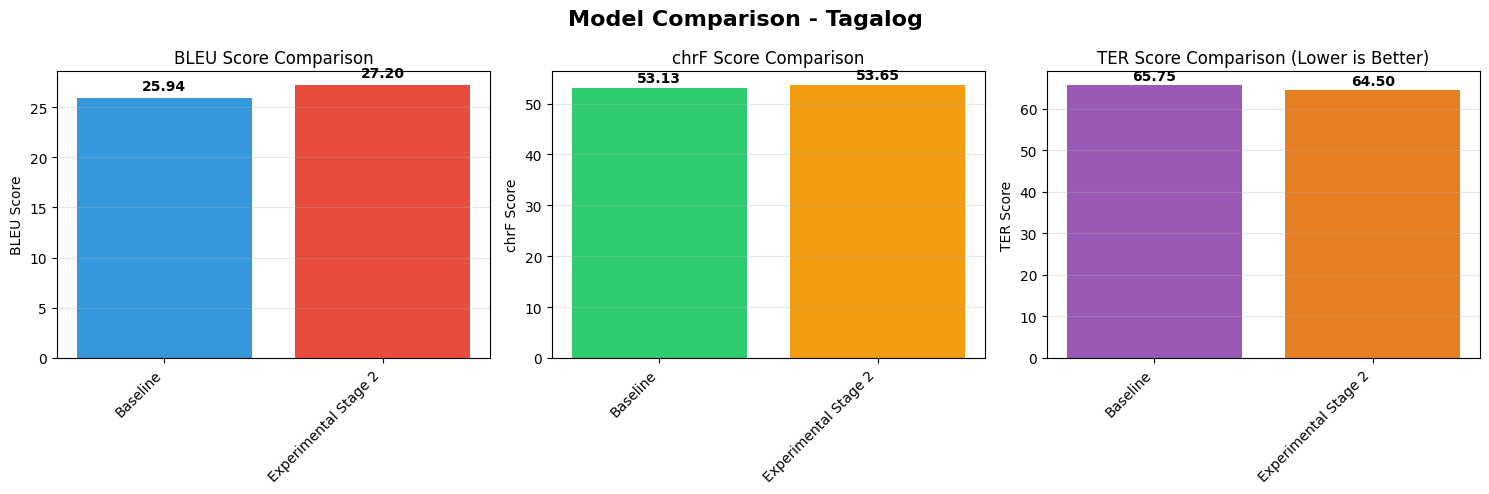

In [8]:
def visualize_comparison(results, target_lang="tagalog"):
    """Create visualization of model comparison."""
    if not results or len(results) < 2:
        print("Not enough results to visualize")
        return
    
    # Prepare data
    model_names = [r['model_type'] for r in results]
    bleu_scores = [r['metrics']['bleu'] for r in results]
    chrf_scores = [r['metrics']['chrf'] for r in results]
    ter_scores = [r['metrics']['ter'] for r in results]
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Model Comparison - {target_lang.capitalize()}', fontsize=16, fontweight='bold')
    
    # BLEU scores
    axes[0].bar(range(len(model_names)), bleu_scores, color=['#3498db', '#e74c3c'])
    axes[0].set_ylabel('BLEU Score')
    axes[0].set_title('BLEU Score Comparison')
    axes[0].set_xticks(range(len(model_names)))
    axes[0].set_xticklabels([name.split('(')[0].strip() for name in model_names], rotation=45, ha='right')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(bleu_scores):
        axes[0].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # chrF scores
    axes[1].bar(range(len(model_names)), chrf_scores, color=['#2ecc71', '#f39c12'])
    axes[1].set_ylabel('chrF Score')
    axes[1].set_title('chrF Score Comparison')
    axes[1].set_xticks(range(len(model_names)))
    axes[1].set_xticklabels([name.split('(')[0].strip() for name in model_names], rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(chrf_scores):
        axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # TER scores (lower is better)
    axes[2].bar(range(len(model_names)), ter_scores, color=['#9b59b6', '#e67e22'])
    axes[2].set_ylabel('TER Score')
    axes[2].set_title('TER Score Comparison (Lower is Better)')
    axes[2].set_xticks(range(len(model_names)))
    axes[2].set_xticklabels([name.split('(')[0].strip() for name in model_names], rotation=45, ha='right')
    axes[2].grid(axis='y', alpha=0.3)
    for i, v in enumerate(ter_scores):
        axes[2].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    viz_file = RESULTS_DIR / f"comparison_{target_lang}_visualization.png"
    plt.savefig(viz_file, dpi=300, bbox_inches='tight')
    print(f"✓ Visualization saved to: {viz_file}")
    
    plt.show()


# Visualize if we have comparison results
if comparison_results:
    visualize_comparison(comparison_results, target_lang="tagalog")

## Batch Validation

Validate all models at once and create comprehensive comparison.

In [9]:
def validate_all_models():
    """Validate all trained models and create comprehensive comparison."""
    print("\n" + "#"*80)
    print("# BATCH VALIDATION - ALL MODELS")
    print("#"*80)
    
    target_languages = ["tagalog", "ilonggo", "waray"]
    pair_mapping = {
        "tagalog": "en-tl",
        "ilonggo": "en-hil",
        "waray": "en-war"
    }
    
    all_results = {}
    
    for target_lang in target_languages:
        pair_name = pair_mapping[target_lang]
        print(f"\n{'='*80}")
        print(f"Processing: {target_lang.upper()} ({pair_name})")
        print("="*80)
        
        try:
            results = compare_models(target_lang=target_lang, pair_name=pair_name)
            if results:
                all_results[target_lang] = results
                visualize_comparison(results, target_lang=target_lang)
        except Exception as e:
            print(f"\n❌ Error processing {target_lang}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Create summary table
    print("\n" + "="*80)
    print("OVERALL SUMMARY - ALL TARGET LANGUAGES")
    print("="*80)
    print(f"{'Language':<15} {'Model':<30} {'BLEU':<10} {'chrF':<10} {'TER':<10}")
    print("-"*80)
    
    for target_lang, results in all_results.items():
        for result in results:
            model_name = result['model_type'].split('(')[0].strip()
            print(f"{target_lang.capitalize():<15} "
                  f"{model_name:<30} "
                  f"{result['metrics']['bleu']:<10.2f} "
                  f"{result['metrics']['chrf']:<10.2f} "
                  f"{result['metrics']['ter']:<10.2f}")
        print("-"*80)
    
    # Save comprehensive results
    comprehensive_file = RESULTS_DIR / "all_models_validation.json"
    with open(comprehensive_file, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"\n✓ Comprehensive results saved to: {comprehensive_file}")
    
    return all_results


# Uncomment to run batch validation
# all_validation_results = validate_all_models()

## Export Results to CSV

Create CSV file for easy analysis in Excel or other tools.

In [10]:
def export_results_to_csv():
    """Export all validation results to CSV."""
    # Load comprehensive results
    comprehensive_file = RESULTS_DIR / "all_models_validation.json"
    
    if not comprehensive_file.exists():
        print("No comprehensive results found. Run batch validation first.")
        return
    
    with open(comprehensive_file, "r") as f:
        all_results = json.load(f)
    
    # Prepare data for DataFrame
    data = []
    for target_lang, results in all_results.items():
        for result in results:
            data.append({
                "Target Language": target_lang.capitalize(),
                "Language Pair": result['pair_name'],
                "Model Type": result['model_type'],
                "Base Model": result['base_model'],
                "LoRA": "Yes" if result['is_lora'] else "No",
                "BLEU Score": result['metrics']['bleu'],
                "chrF Score": result['metrics']['chrf'],
                "TER Score": result['metrics']['ter'],
                "Test Size": result['test_size'],
                "Translation Time (s)": result['translation_time'],
                "Sentences/Second": result['sentences_per_second'],
                "Timestamp": result['timestamp']
            })
    
    # Create DataFrame
    df = pd.DataFrame(data)
    
    # Sort by target language and BLEU score
    df = df.sort_values(["Target Language", "BLEU Score"], ascending=[True, False])
    
    # Save to CSV
    csv_file = RESULTS_DIR / "validation_results.csv"
    df.to_csv(csv_file, index=False)
    print(f"✓ Results exported to: {csv_file}")
    
    # Display summary
    print("\nResults Summary:")
    print(df.to_string(index=False))
    
    return df


# Uncomment to export results
# results_df = export_results_to_csv()

## Memory Cleanup

In [11]:
import gc

print("🧹 Cleaning up memory...")

# Clear Python garbage collector
gc.collect()

# Clear PyTorch CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    
    print(f"✓ CUDA cache cleared")
    print(f"  GPU Memory Allocated: {allocated:.2f} GB")
    print(f"  GPU Memory Reserved:  {reserved:.2f} GB")
else:
    print("✓ Garbage collection complete (No GPU available)")

print("\n💾 Memory cleanup complete!")

🧹 Cleaning up memory...
✓ CUDA cache cleared
  GPU Memory Allocated: 0.01 GB
  GPU Memory Reserved:  0.02 GB

💾 Memory cleanup complete!
✓ CUDA cache cleared
  GPU Memory Allocated: 0.01 GB
  GPU Memory Reserved:  0.02 GB

💾 Memory cleanup complete!


## Summary

### What This Notebook Does

This notebook provides comprehensive validation and evaluation of trained MT models:

1. **Load Models:** Supports both full fine-tuned and LoRA models (mBART-50 and NLLB-200)
2. **Test Set Evaluation:** Evaluates on held-out test data
3. **Multiple Metrics:** Calculates BLEU, chrF, and TER scores
4. **Batch Translation:** Efficient batch processing with beam search
5. **Model Comparison:** Side-by-side comparison of baseline vs experimental models
6. **Visualization:** Creates bar charts comparing performance
7. **Export:** Saves results to JSON and CSV for further analysis

### Key Features

- ⚡ **GPU Acceleration:** Uses CUDA and BF16 when available
- 🔍 **Beam Search:** Uses beam search (num_beams=5) for better quality translations
- 📊 **Multiple Metrics:** BLEU (standard), chrF (character-level), TER (edit distance)
- 🎯 **Sample Translations:** Shows actual translation examples for qualitative analysis
- 💾 **Result Persistence:** Saves all results for reproducibility

### Metrics Explained

- **BLEU Score:** Measures n-gram overlap with reference (0-100, higher is better)
- **chrF Score:** Character-level F-score (0-100, higher is better)
- **TER Score:** Translation Edit Rate (0-100, lower is better)

### Usage Tips

1. Start with single model validation to verify setup
2. Use comparison function to evaluate baseline vs experimental
3. Run batch validation for all models at once
4. Export to CSV for analysis in Excel or Python
5. Check sample translations for qualitative assessment

### Output Files

```
results/
  ├── validation_{pair}_baseline.json
  ├── validation_{pair}_experimental.json
  ├── translations_{pair}_baseline.txt
  ├── translations_{pair}_experimental.txt
  ├── comparison_{target_lang}_{pair}.json
  ├── comparison_{target_lang}_visualization.png
  ├── all_models_validation.json
  └── validation_results.csv
```

### Next Steps

After validation:
1. Analyze which model performs best
2. Review sample translations for error patterns
3. Compare across different target languages
4. Evaluate if similarity transfer actually helps
5. Consider additional fine-tuning based on results